In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
B_c = 280
R_n = 3.9
nu = 0.3

h_km = np.linspace(0, 120, 1000)
h_m = h_km * 1000
rho_sea = 1.225
h_sea = 7200
R_earth = 6371e3
mu = 3.986e14
rho = rho_sea*np.exp(-h_m/h_sea)
g = mu/(R_earth + h_m)**2

In [53]:
q_max = 60e4
a_max = 4*9.81

In [54]:
v_heatload = 1e-3*(q_max/(1.45e-4*np.sqrt(rho/R_n)))**(1.0/3.0)
v_gload = 1e-3*np.sqrt(2*B_c*a_max/(rho*np.sqrt(1+nu**2)))

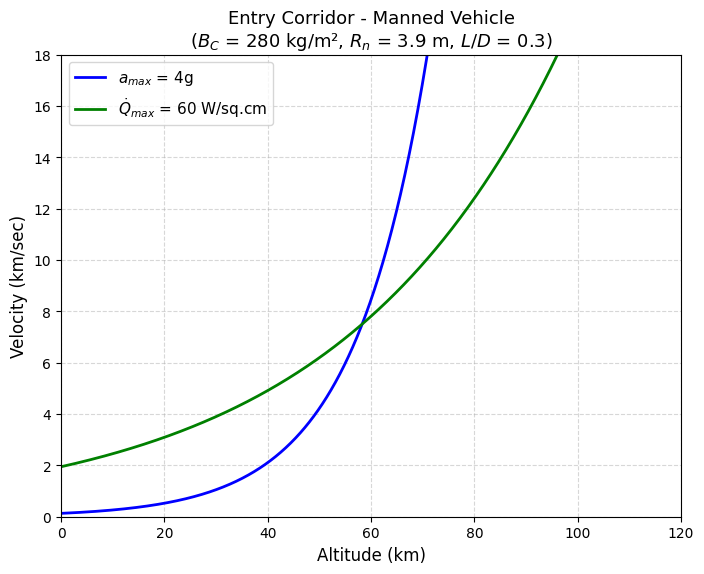

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(h_km, v_gload, color='blue', linewidth=2, label=r'$a_{max}$ = 4g')
ax.plot(h_km, v_heatload,  color='green',  linewidth=2, label=r'$\dot{Q}_{max}$ = 60 W/sq.cm')
ax.set_xlim(0, 120)
ax.set_ylim(0, 18)
ax.set_title('Entry Corridor - Manned Vehicle\n'
             r'($B_C$ = 280 kg/m², $R_n$ = 3.9 m, $L/D$ = 0.3)',
             fontsize=13)
ax.set_ylabel('Velocity (km/sec)', fontsize=12)
ax.set_xlabel('Altitude (km)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(fontsize=11, loc='upper left')

In [45]:
q_max = 500e4
a_max = 20*9.81

B_c = 72.6
R_n = 2

In [46]:
v_heatload = 1e-3*(q_max/(1.45e-4*np.sqrt(rho/R_n)))**(1.0/3.0)
v_gload = 1e-3*np.sqrt(2*B_c*a_max/(rho*np.sqrt(1+nu**2)))

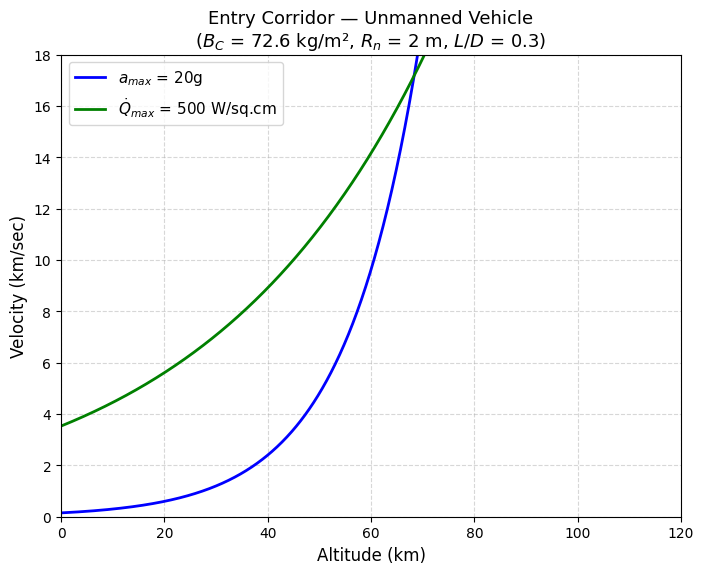

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(h_km, v_gload, color='blue', linewidth=2, label=r'$a_{max}$ = 20g')
ax.plot(h_km, v_heatload,  color='green',  linewidth=2, label=r'$\dot{Q}_{max}$ = 500 W/sq.cm')
ax.set_xlim(0, 120)
ax.set_ylim(0, 18)
ax.set_title('Entry Corridor — Unmanned Vehicle\n'
             r'($B_C$ = 72.6 kg/m², $R_n$ = 2 m, $L/D$ = 0.3)',
             fontsize=13)
ax.set_ylabel('Velocity (km/sec)', fontsize=12)
ax.set_xlabel('Altitude (km)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(fontsize=11, loc='upper left')

Running Ballistic Entry Simulation...


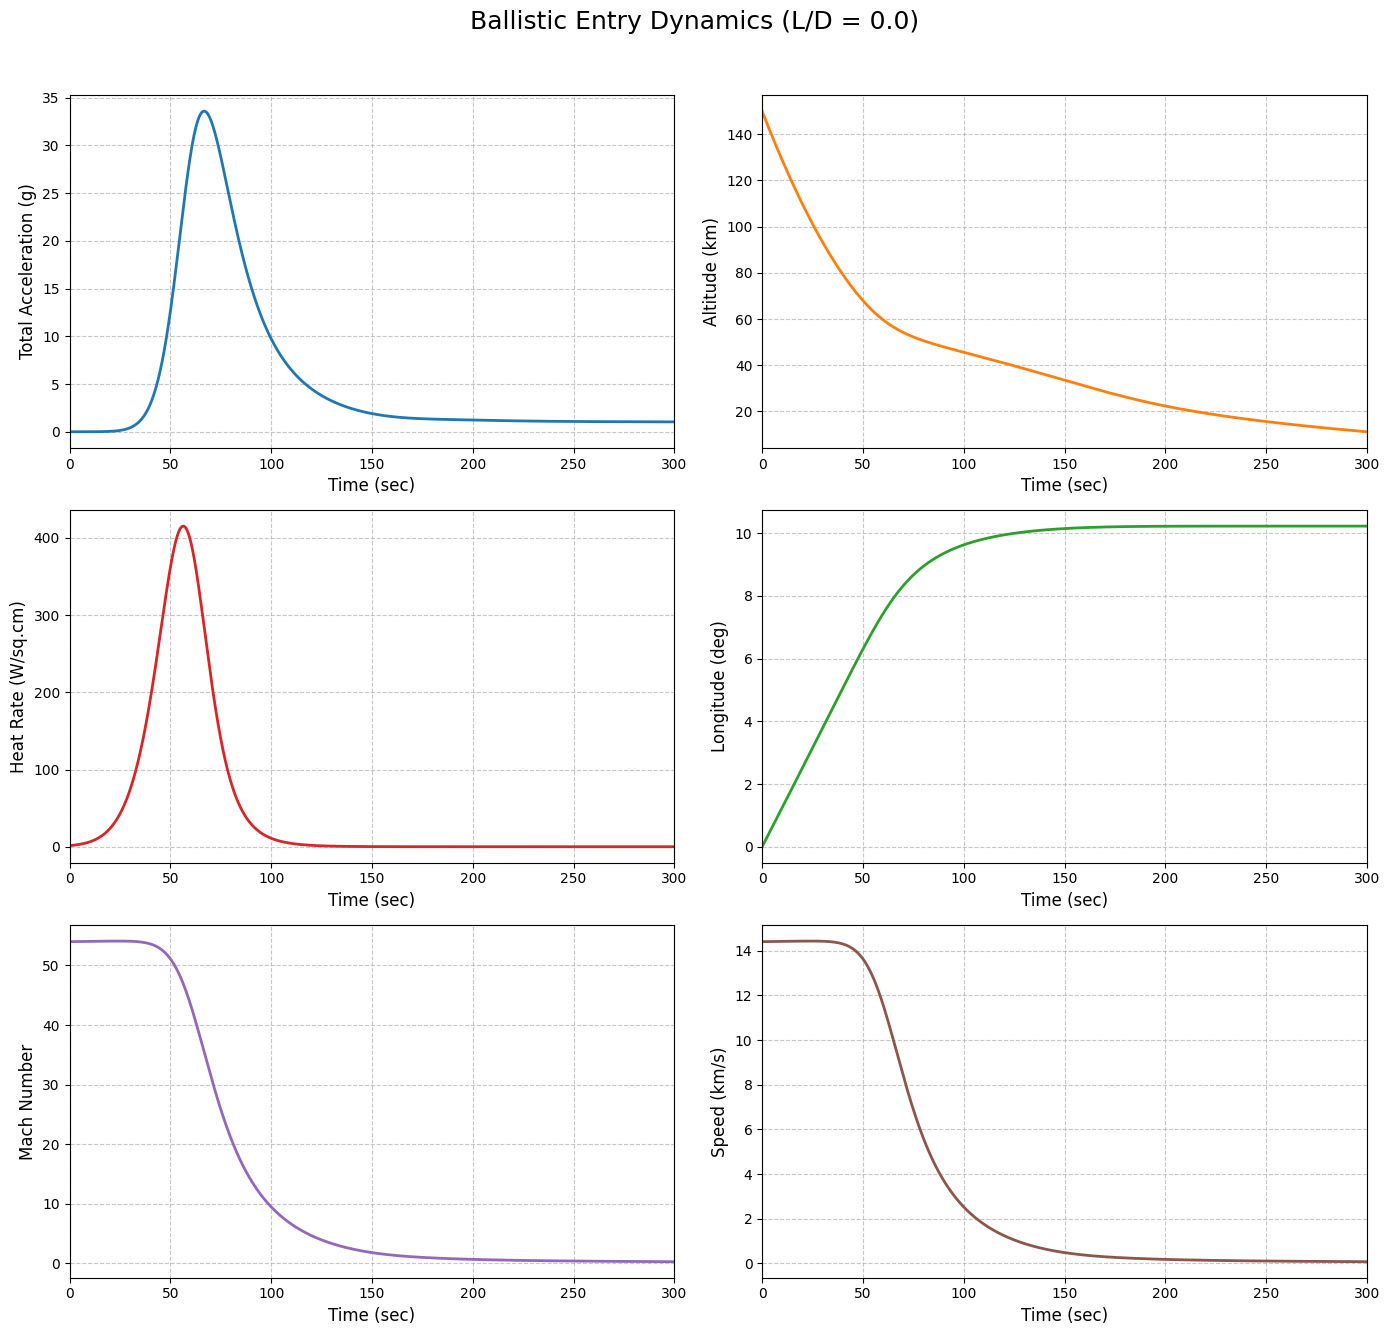

Running Lifting Entry Simulation (Skip Trajectory)...


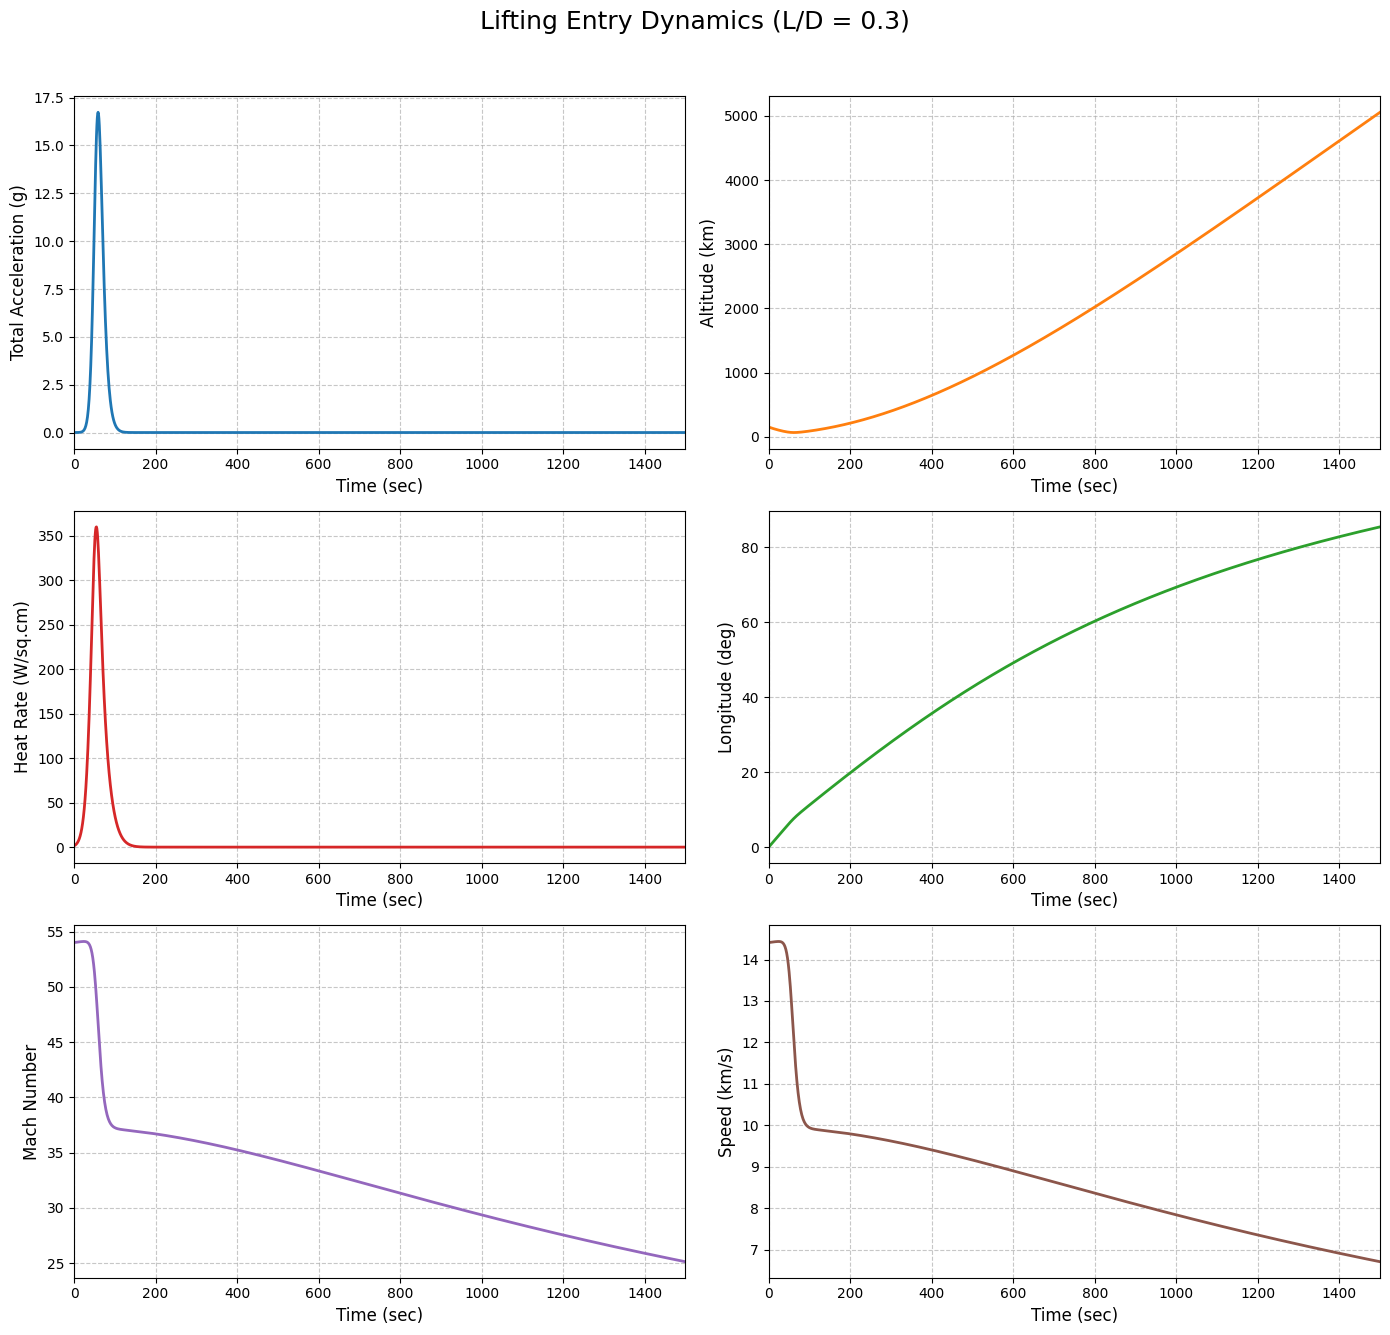

In [56]:
# ==========================================
# REENTRY DYNAMICS SIMULATION (GOOGLE COLAB)
# Based on Chapter 2: Reentry Dynamics
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. CONSTANTS & VEHICLE PARAMETERS ---
MU = 398600.0             # Earth's gravitational parameter (km^3/s^2)
R_EARTH = 6371.0          # Earth's mean radius (km)
OMEGA_E = 7.2921e-5       # Earth's rotation rate (rad/s)
RHO_SEA = 1.225e9         # Sea-level atmospheric density (kg/km^3)
H_SEA = 7.2               # Density scale height (km)
G0 = 0.00980665           # Standard gravity for g-load calculation (km/s^2)

MASS = 400.0              # Vehicle mass (kg)
BC = 72.6e6               # Ballistic coefficient (kg/km^2)
R_NOSE = 1.0              # Nose radius (meters)

# Speed of sound used to match the paper's Mach 54 peak at 14.41 km/s.
SPEED_OF_SOUND_KM_S = 0.26685 

# --- 2. EQUATIONS OF MOTION ---
def reentry_dynamics(t, state, L_D):
    theta, delta, r, v, chi, gamma = state
    
    # Altitude and Density (Exponential Model)
    h = r - R_EARTH
    rho = RHO_SEA * np.exp(-h / H_SEA) if h > 0 else RHO_SEA
    
    # Gravity
    g = MU / (r**2)
    
    # Aerodynamic Forces (Mass-normalized: km/s^2)
    D_m = 0.5 * rho * (v**2) / BC
    L_m = D_m * L_D
    
    # Total forces in wind frame (including gravity components)
    F1_M = -D_m - g * np.sin(gamma)
    F2_M = 0.0 # Assuming no side-slip or bank angle
    F3_M = L_m - g * np.cos(gamma)
    
    # State Derivatives (Eqs 2.4 - 2.9)
    dtheta = (v / r) * np.cos(gamma) * np.sin(chi) / np.cos(delta)
    ddelta = (v / r) * np.cos(gamma) * np.cos(chi)
    dr     = v * np.sin(gamma)
    
    dv = (OMEGA_E**2) * r * np.cos(delta) * \
         (-np.cos(gamma) * np.cos(chi) * np.cos(delta) + np.sin(gamma) * np.cos(delta)) + F1_M
         
    dchi = 2 * OMEGA_E * (-np.tan(gamma) * np.cos(chi) * np.cos(delta) + np.sin(delta)) + \
           ((OMEGA_E**2) * r / (v * np.cos(gamma))) * np.sin(chi) * np.cos(delta) * np.sin(delta) + \
           (v / r) * np.cos(gamma) * np.sin(chi) * np.tan(delta) + \
           (F2_M / (v * np.cos(gamma)))
           
    dgamma = 2 * OMEGA_E * np.sin(chi) * np.cos(delta) + \
             ((OMEGA_E**2) * r / v) * np.cos(delta) * \
             (np.sin(gamma) * np.cos(chi) * np.sin(delta) + np.cos(gamma) * np.cos(delta)) + \
             (v / r) * np.cos(gamma) + (F3_M / v)
             
    return [dtheta, ddelta, dr, dv, dchi, dgamma]

# --- 3. SIMULATION & PLOTTING ROUTINE ---
def run_and_plot(L_D, t_end, title_prefix):
    # Initial Conditions (Angles must be in radians for calculation)
    v0     = 14.41                  # km/s
    gamma0 = np.radians(-8.99)      # rad
    theta0 = np.radians(0.0)        # rad
    delta0 = np.radians(0.0)        # rad
    r0     = R_EARTH + 150.0        # km
    chi0   = np.radians(90.0)       # rad
    
    state0 = [theta0, delta0, r0, v0, chi0, gamma0]
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, 1500)
    
    # Run Numerical Integration
    sol = solve_ivp(reentry_dynamics, t_span, state0, args=(L_D,), 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
    
    # Extract results
    t_out = sol.t
    theta = np.degrees(sol.y[0])  # Convert back to degrees
    r     = sol.y[2]
    v     = sol.y[3]
    h     = r - R_EARTH
    
    # Calculate Auxiliary Variables
    g_load = []
    heat_rate = []
    mach_no = []
    
    for i in range(len(t_out)):
        current_h = h[i]
        current_v = v[i]
        
        # Recalculate density for auxiliary constraints
        rho = RHO_SEA * np.exp(-current_h / H_SEA) if current_h > 0 else RHO_SEA
        
        # Total Acceleration (g-load) purely from aerodynamic forces
        D_m = 0.5 * rho * (current_v**2) / BC
        L_m = D_m * L_D
        g_accel = np.sqrt(L_m**2 + D_m**2) / G0
        g_load.append(g_accel)
        
        # Heat Rate (Eq 2.1)
        rho_kg_m3 = rho * 1e-9          # Convert kg/km^3 to kg/m^3
        v_m_s = current_v * 1000.0      # Convert km/s to m/s
        q_w_m2 = 1.45e-4 * np.sqrt(rho_kg_m3 / R_NOSE) * (v_m_s**3)
        heat_rate.append(q_w_m2 / 10000.0)
        
        # Mach Number
        mach_no.append(current_v / SPEED_OF_SOUND_KM_S)
        
    # Colab Plotting Display
    fig, axs = plt.subplots(3, 2, figsize=(14, 14), dpi=100) # Slightly larger/higher DPI for Colab
    fig.suptitle(f'{title_prefix} Entry Dynamics (L/D = {L_D})', fontsize=18, y=0.98)
    
    def setup_axis(ax, x, y, ylabel, color):
        ax.plot(x, y, color, linewidth=2)
        ax.set_xlabel('Time (sec)', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlim([0, t_end])

    setup_axis(axs[0, 0], t_out, g_load, 'Total Acceleration (g)', '#1f77b4')
    setup_axis(axs[0, 1], t_out, h, 'Altitude (km)', '#ff7f0e')
    setup_axis(axs[1, 0], t_out, heat_rate, 'Heat Rate (W/sq.cm)', '#d62728')
    setup_axis(axs[1, 1], t_out, theta, 'Longitude (deg)', '#2ca02c')
    setup_axis(axs[2, 0], t_out, mach_no, 'Mach Number', '#9467bd')
    setup_axis(axs[2, 1], t_out, v, 'Speed (km/s)', '#8c564b')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

# --- 4. EXECUTE SCENARIOS ---
print("Running Ballistic Entry Simulation...")
run_and_plot(L_D=0.0, t_end=300, title_prefix='Ballistic')

print("Running Lifting Entry Simulation (Skip Trajectory)...")
run_and_plot(L_D=0.3, t_end=1500, title_prefix='Lifting')